In [1]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# Define the custom color palette and genotype order
# new_colors_order = sns.color_palette(palette='Set2', n_colors=3)
# new_colors_order[0], new_colors_order[1], new_colors_order[2] = new_colors_order[1], new_colors_order[0], new_colors_order[2]
# color_map = dict(zip(['wt', 'het', 'hom'], new_colors_order))

# Define input variables
date   = "250214"
box1   = "14"
box2   = "15"
exp    = "ALDH7A1_20LYS_7dpf"
export = False

omit = {box1:['H7','D8','D9','D12']}
    
ald_lys_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df
df_raw = ald_lys_obj_raw.df

Initialising RawData...
Start of experiment: 2025-02-14 10:07:08
Instantiated using 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv, no need to prepare raw data.
Done.


/var/folders/99/9p1rqw911_b36bj9w7ly35q80000gn/T/ipykernel_10406/1348297726.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_smoothed = df.groupby(["box", "well"], group_keys=False).apply(smooth_group, sigma=sigma_value)


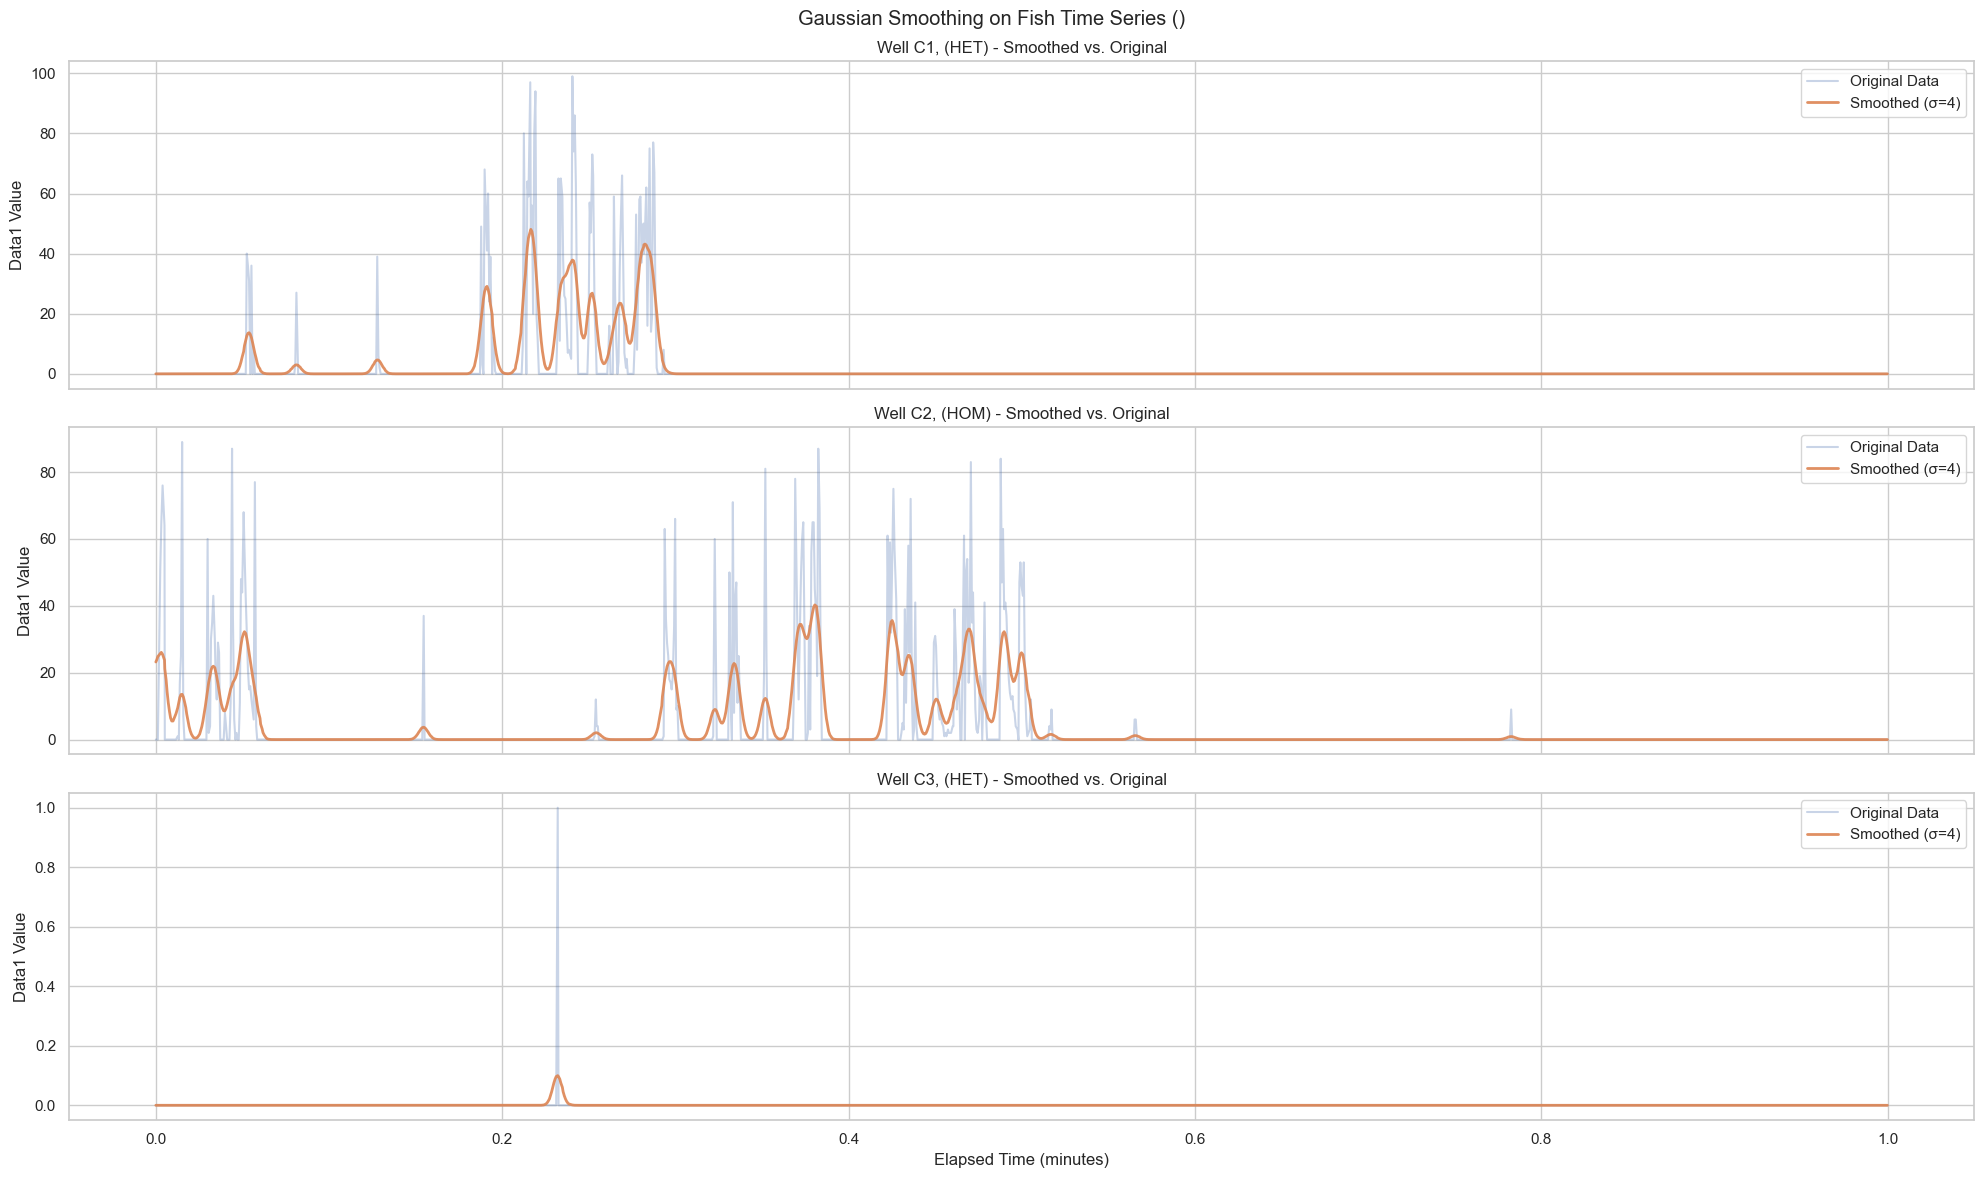

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

df = df_raw

# Convert elapsed_time to numeric (if needed)
df["elapsed_time"] = pd.to_numeric(df["elapsed_time"], errors="coerce")

# Function to apply Gaussian smoothing per fish (grouped by box and well)
def smooth_group(group, sigma=5):
    group = group.sort_values(by="elapsed_time")  # Ensure chronological order
    group["smoothed_data1"] = gaussian_filter1d(group["data1"], sigma=sigma)  # Apply smoothing
    return group

# Apply smoothing to each fish individually
sigma_value = 4  # Adjust smoothing level
df_smoothed = df.groupby(["box", "well"], group_keys=False).apply(smooth_group, sigma=sigma_value)

# **Filter by time elapsed in minutes**
df_smoothed_10min = df_smoothed[df_smoothed["elapsed_time"] <= 1]  # Now correctly using minutes

# **Select a few example wells to plot separately**
example_wells = df_smoothed_10min["well"].unique()[24:27]  # Pick first 3 wells
# example_wells = df_smoothed_10min["well"].unique()[24:28]  # Pick first 3 wells
num_wells = len(example_wells)

# Set up separate subplots for each well
fig, axes = plt.subplots(num_wells, 1, figsize=(20, 4 * num_wells), sharex=True)

if num_wells == 1:  # Ensure `axes` is iterable even if there's only one plot
    axes = [axes]

for ax, well in zip(axes, example_wells):
    well_data = df_smoothed_10min[df_smoothed_10min["well"] == well]
    genotype  = well_data['genotype'].unique()[0]
    ax.plot(well_data["elapsed_time"], well_data["data1"], alpha=0.3, linestyle="solid", label="Original Data")
    ax.plot(well_data["elapsed_time"], well_data["smoothed_data1"], label=f"Smoothed (σ={sigma_value})", linewidth=2, alpha=0.9)
    ax.set_title(f"Well {well}, ({genotype}) - Smoothed vs. Original")
    ax.set_ylabel("Data1 Value")
    ax.legend()

# Set common x-label
plt.xlabel("Elapsed Time (minutes)")
plt.suptitle("Gaussian Smoothing on Fish Time Series ()")
plt.tight_layout()
plt.show()

In [21]:
df_smoothed[df_smoothed['well']=='A2']

,fullts,elapsed_time,box,well,genotype,data1,smoothed_data1
1,2025-02-14 10:07:08.027045000,0.000000,14,A2,HOM,0.0,25.870186
64,2025-02-14 10:07:08.059016000,0.000533,14,A2,HOM,0.0,26.380693
127,2025-02-14 10:07:08.097652000,0.001177,14,A2,HOM,38.0,27.336302
190,2025-02-14 10:07:08.180832000,0.002563,14,A2,HOM,30.0,28.613499
253,2025-02-14 10:07:08.217890000,0.003181,14,A2,HOM,54.0,30.045716
...,...,...,...,...,...,...,...
18415657,2025-02-14 13:22:32.250190000,195.403719,14,A2,HOM,0.0,0.000000
18415720,2025-02-14 13:22:32.297120000,195.404501,14,A2,HOM,0.0,0.000000
18415783,2025-02-14 13:22:32.340895000,195.405231,14,A2,HOM,0.0,0.000000
18415846,2025-02-14 13:22:32.377325000,195.405838,14,A2,HOM,0.0,0.000000


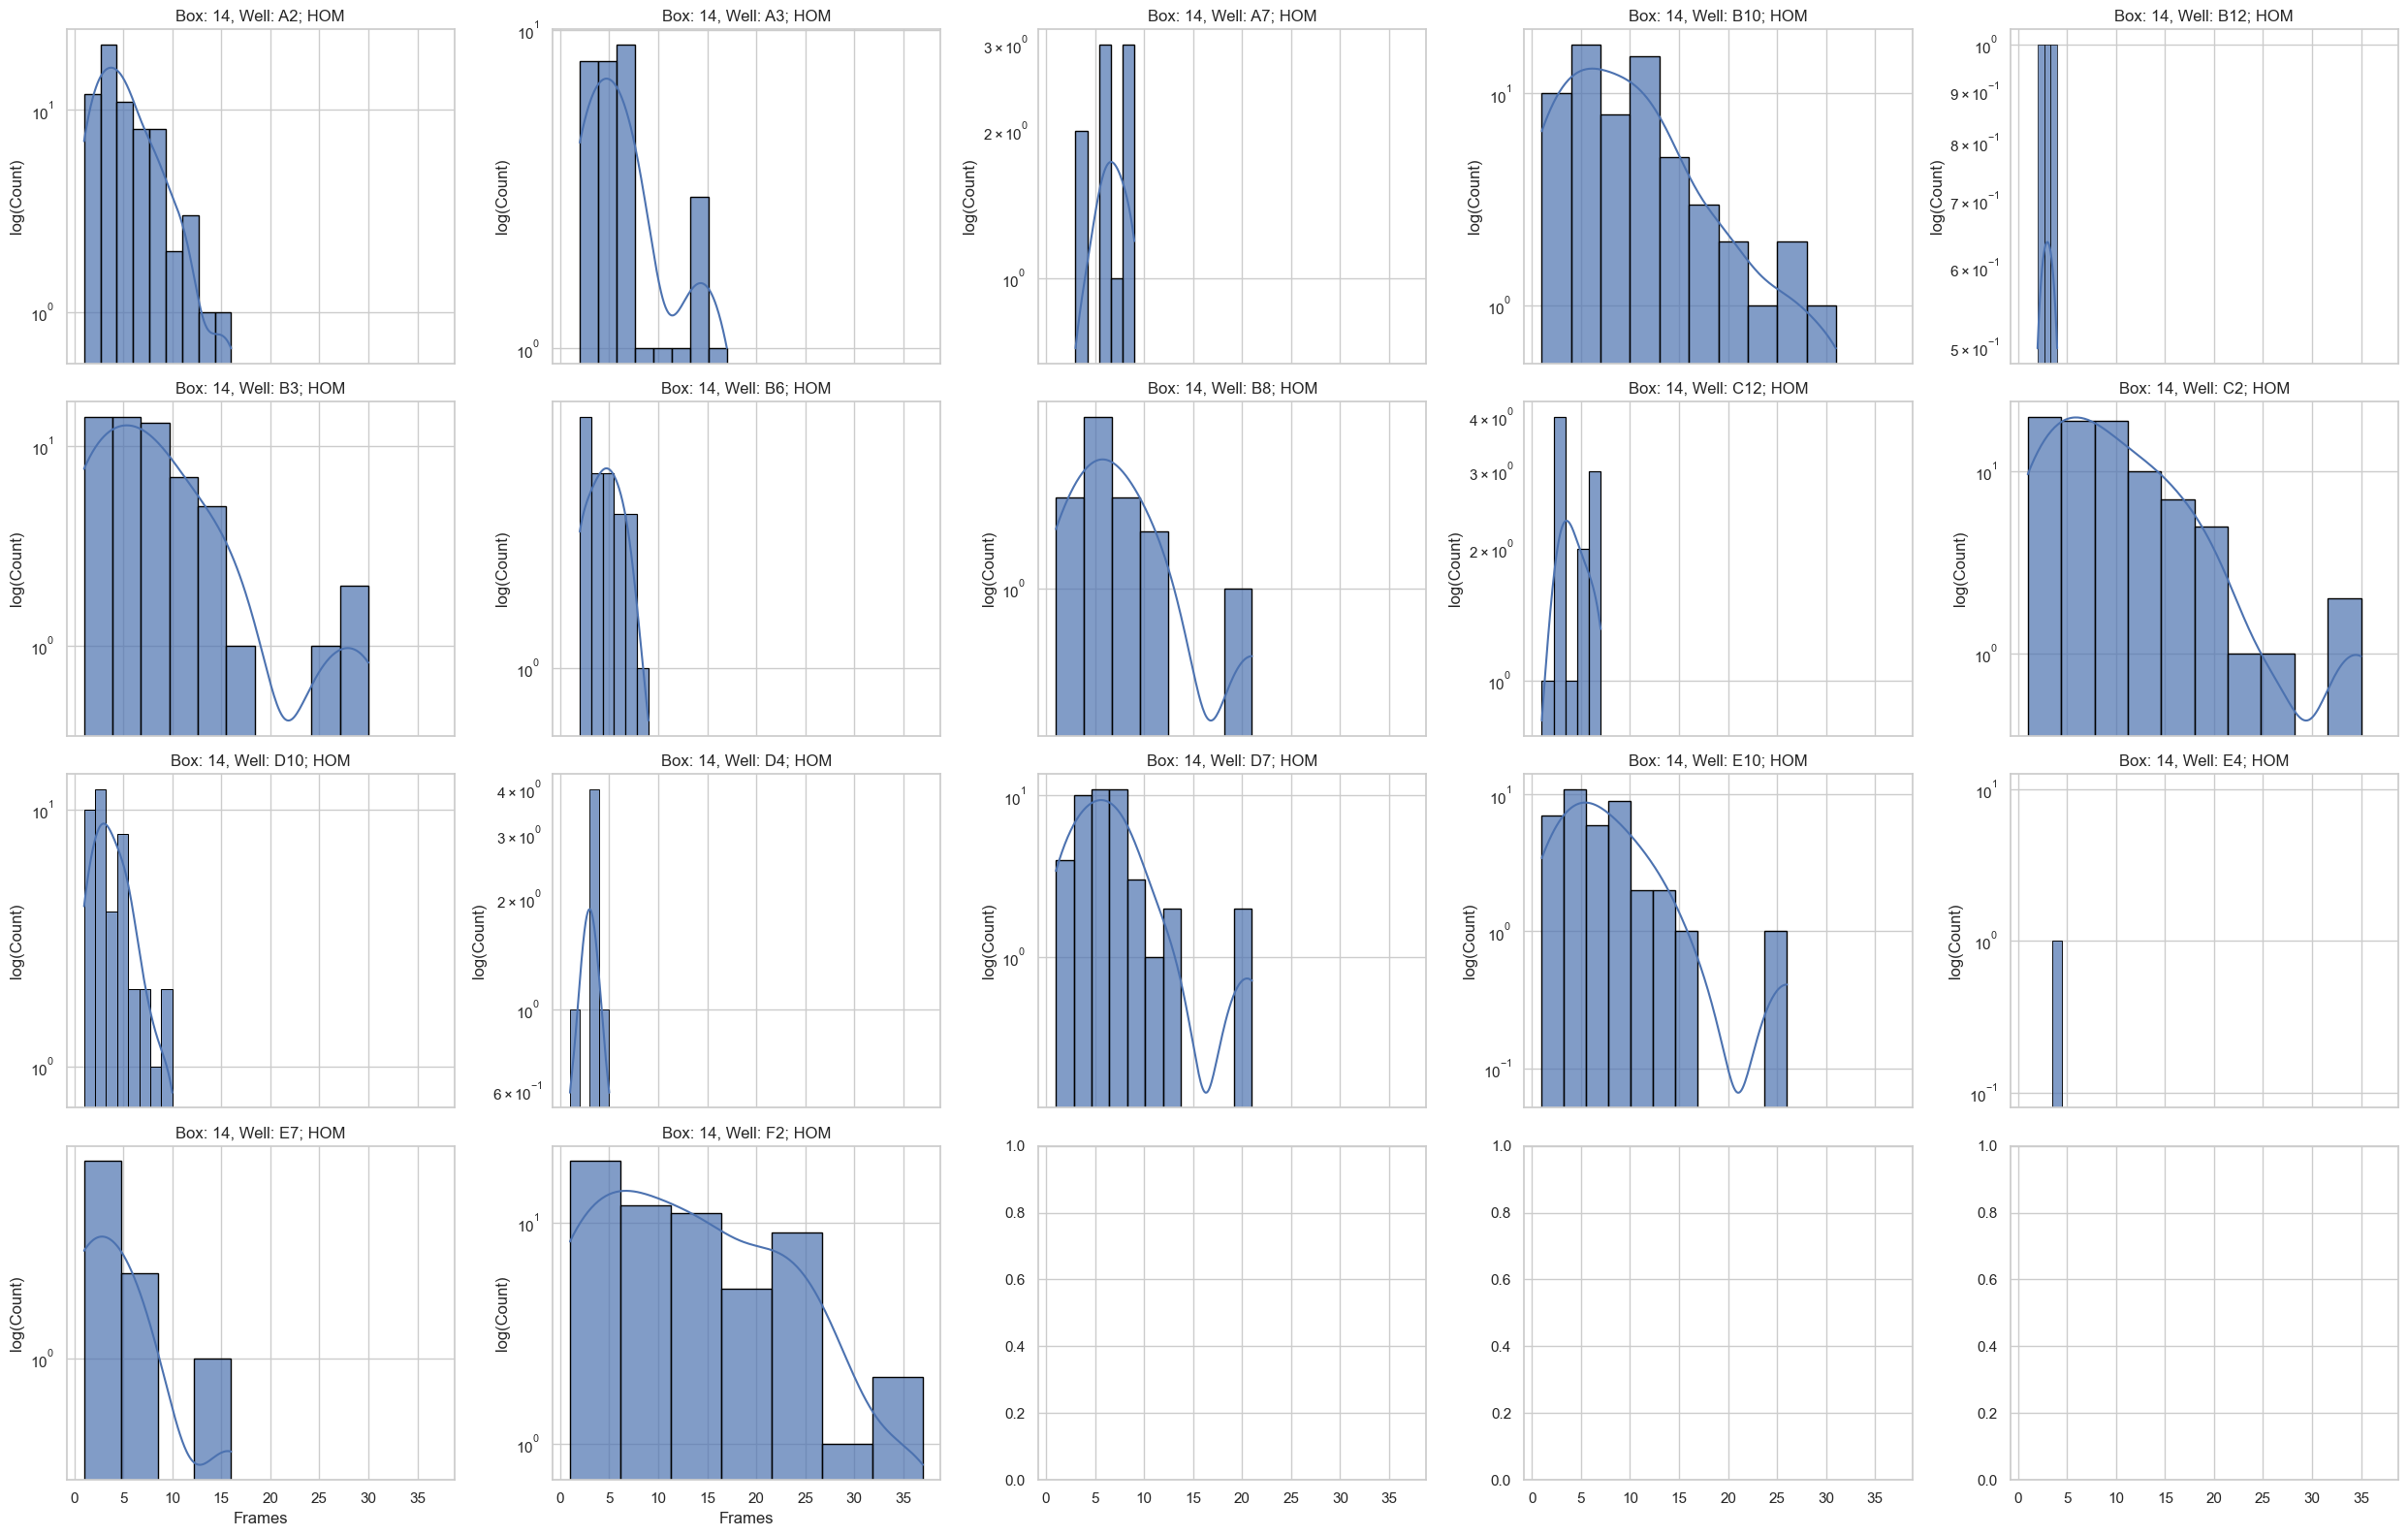

In [39]:
all_homs = df_raw[df_raw["genotype"] == "HOM"]
all_homs_grouped = list(all_homs.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_homs_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list, full_df=df_smoothed, col='smoothed_data1')

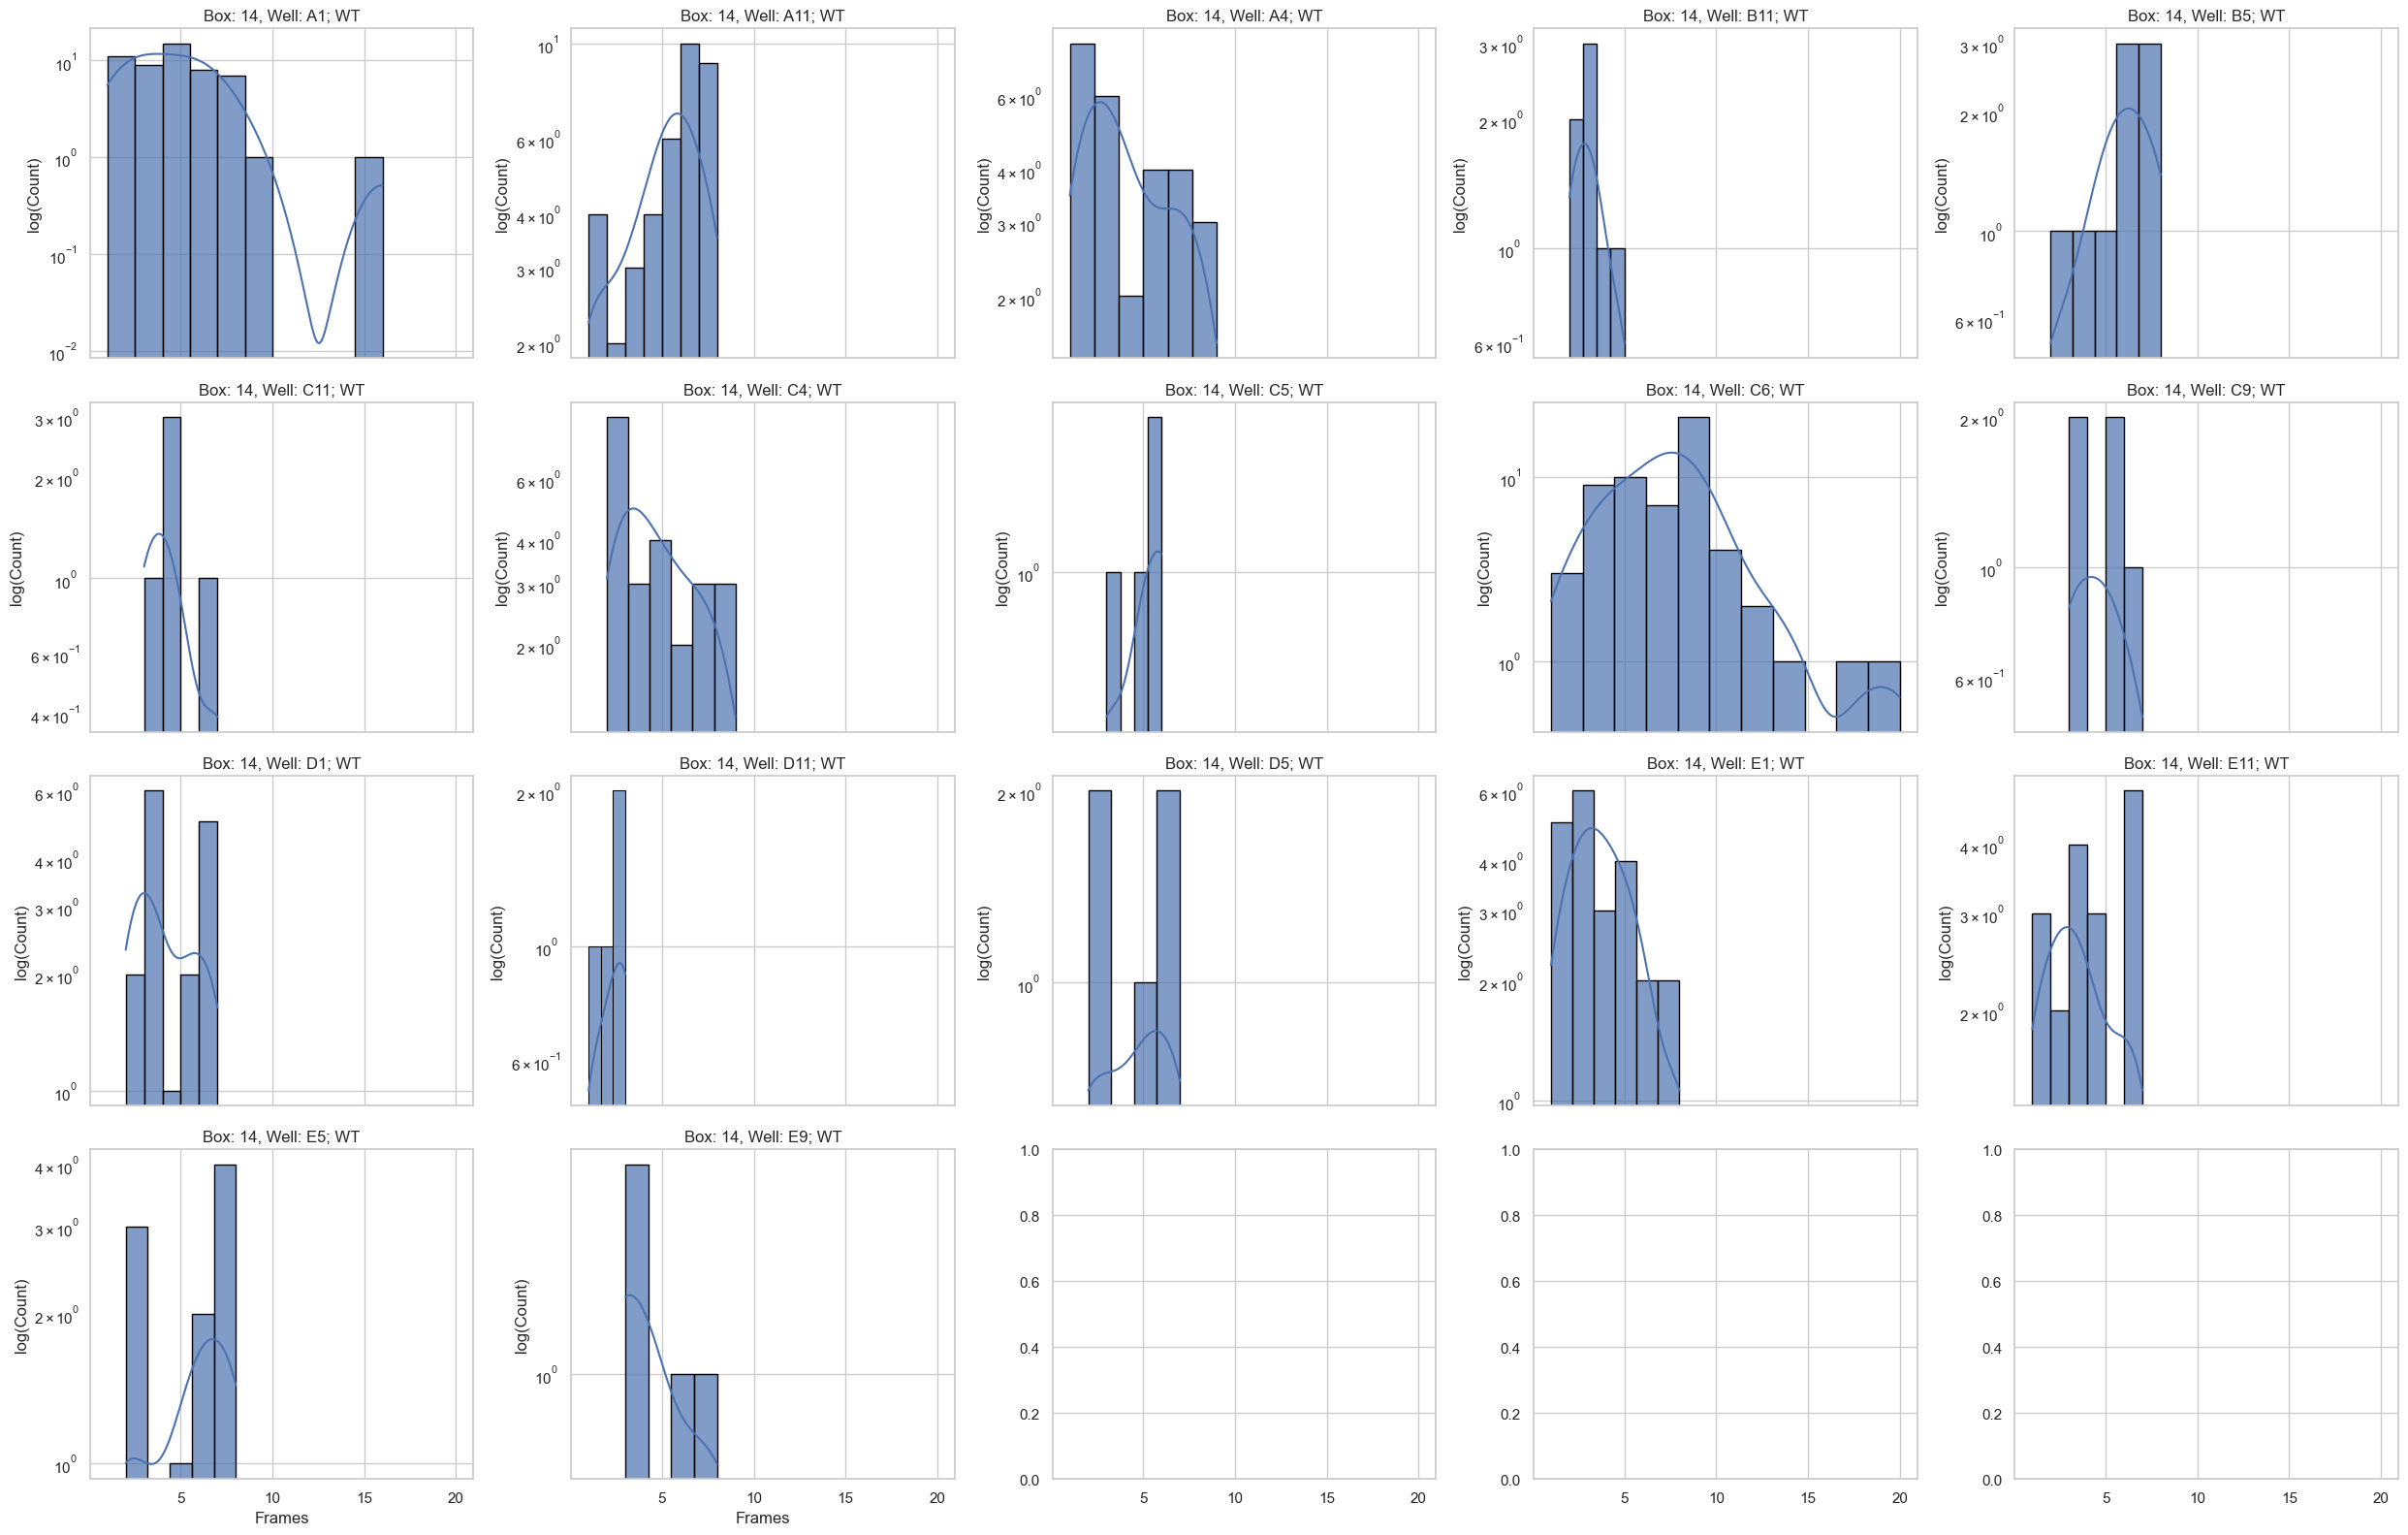

In [40]:
all_wts = df_raw[df_raw["genotype"] == "WT"]
all_wts_grouped = list(all_wts.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_wts_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list, full_df=df_smoothed, col='smoothed_data1')


In [ ]:



fishC2        = df_raw[df_raw['well'] == 'C2'] #HOM

# Define threshold
threshold = 40

# Ensure data is sorted by time
df = fishC2.sort_values(by="fullts")

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
frame_count = 0
count_durations = []  # List to store number of frames in each threshold exceedance
above_threshold = False  # Track whether we're in a threshold-exceeding period

# Iterate through dataframe using .itertuples() (more efficient)
for row in df.itertuples(index=False):
    if row.above_threshold:
        if not above_threshold:  # First frame crossing threshold
            frame_count = 1  # Start counting
            above_threshold = True
        else:
            frame_count += 1  # Keep counting frames
    else:
        if above_threshold:  # Just dropped below threshold
            count_durations.append(frame_count)  # Store frame count
            above_threshold = False
            frame_count = 0  # Reset counter

# If the last value was still above the threshold, store the final count
if above_threshold:
    count_durations.append(frame_count)

# Output the frame count durations
print(f"Frame counts where data1 exceeded the threshold ({start}, {end}):", count_durations)
# fishA1_count_durations = count_durations
# ax = sns.histplot(fishA1_count_durations, kde=True, edgecolor="black", alpha=0.7)
# ax.set_yscale("log")

In [43]:
# Filter for the specific well
fishC2 = df_raw[df_raw['well'] == 'C2']  # HOM

# Define thresholds
threshold = 40  # Activity level for potential seizure
lower_bound = 5  # Defines "zero" or near-zero baseline
min_duration = 8  # Minimum frames required to qualify as a seizure event
min_ibi = 8  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time
df = fishC2.sort_values(by="fullts").reset_index(drop=True)

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
seizure_events = []  # Stores (start_frame, end_frame, duration, IBI)
in_seizure = False  # Flag to track if we're currently in a seizure
start_frame = None  # To store the start of the bout
end_frame = None  # To store the end of the bout
last_end_frame = None  # Tracks the last confirmed event's end

# Iterate over DataFrame rows
for i, row in df.iterrows():
    if row["above_threshold"]:
        if not in_seizure:  # First frame crossing threshold
            # Look backward to find the start of the bout
            for j in range(i, -1, -1):
                if df.loc[j, "data1"] <= lower_bound:  # Find last zero (or close)
                    start_frame = j
                    break
            in_seizure = True  # Mark that we're in a seizure
    else:
        if in_seizure:  # Just dropped below threshold
            # Look forward to confirm the actual end
            for j in range(i, len(df)):
                if df.loc[j, "data1"] <= lower_bound:  # Ensure we reached baseline
                    end_frame = j
                    break
            duration = end_frame - start_frame

            if duration > min_duration:  # Only register if duration > 8 frames
                if last_end_frame is not None:
                    ibi = start_frame - last_end_frame  # Interbout interval
                else:
                    ibi = None  # No previous event to compare
                
                # Merge with the last event if IBI is too short
                if ibi is not None and ibi <= min_ibi:
                    # Extend the last event instead of creating a new one
                    last_event = seizure_events.pop()
                    new_event = (last_event[0], end_frame, end_frame - last_event[0], last_event[3])
                    seizure_events.append(new_event)
                else:
                    # Store as a new seizure event
                    seizure_events.append((start_frame, end_frame, duration, ibi))

                last_end_frame = end_frame  # Update last end frame
            in_seizure = False  # Reset flag
            start_frame = None
            end_frame = None

# If the last detected bout is still active at the end, close it
if in_seizure:
    duration = len(df) - 1 - start_frame
    if duration > min_duration:
        ibi = start_frame - last_end_frame if last_end_frame is not None else None
        seizure_events.append((start_frame, len(df) - 1, duration, ibi))

# Output detected seizure events with IBI
for event in seizure_events:
    print(f"Seizure from frame {event[0]} to {event[1]} (Duration: {event[2]} frames, IBI: {event[3]} frames)")

Seizure from frame 45 to 54 (Duration: 9 frames, IBI: None frames)
Seizure from frame 70 to 85 (Duration: 15 frames, IBI: 16 frames)
Seizure from frame 436 to 449 (Duration: 13 frames, IBI: 351 frames)
Seizure from frame 548 to 573 (Duration: 25 frames, IBI: 99 frames)
Seizure from frame 629 to 638 (Duration: 9 frames, IBI: 56 frames)
Seizure from frame 696 to 706 (Duration: 10 frames, IBI: 58 frames)
Seizure from frame 725 to 739 (Duration: 14 frames, IBI: 19 frames)
Seizure from frame 8698 to 8716 (Duration: 18 frames, IBI: 7959 frames)
Seizure from frame 10018 to 10029 (Duration: 11 frames, IBI: 1302 frames)
Seizure from frame 10195 to 10211 (Duration: 16 frames, IBI: 166 frames)
Seizure from frame 10652 to 10661 (Duration: 9 frames, IBI: 441 frames)
Seizure from frame 10953 to 10993 (Duration: 40 frames, IBI: 292 frames)
Seizure from frame 18374 to 18386 (Duration: 12 frames, IBI: 7381 frames)
Seizure from frame 19024 to 19043 (Duration: 19 frames, IBI: 638 frames)
Seizure from fra

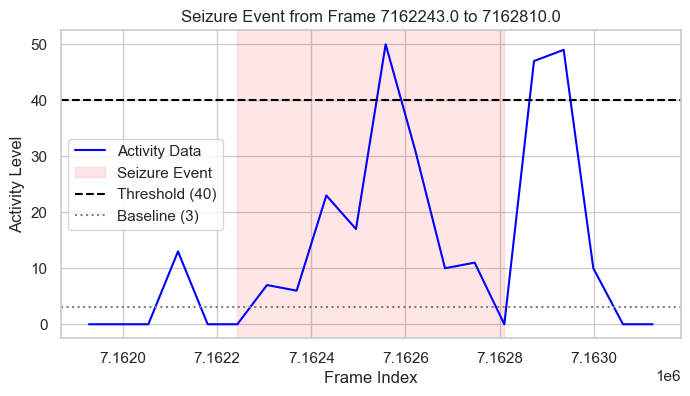

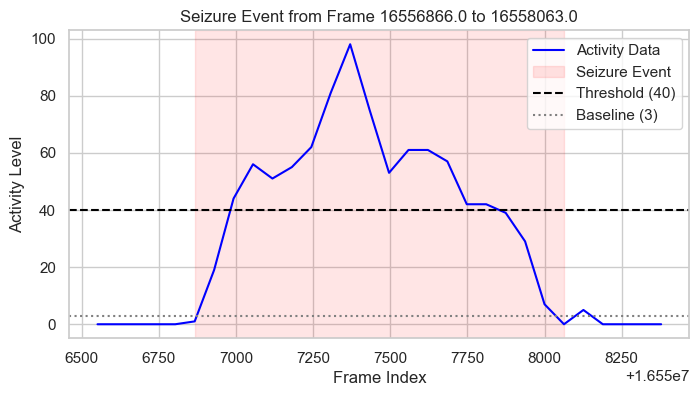

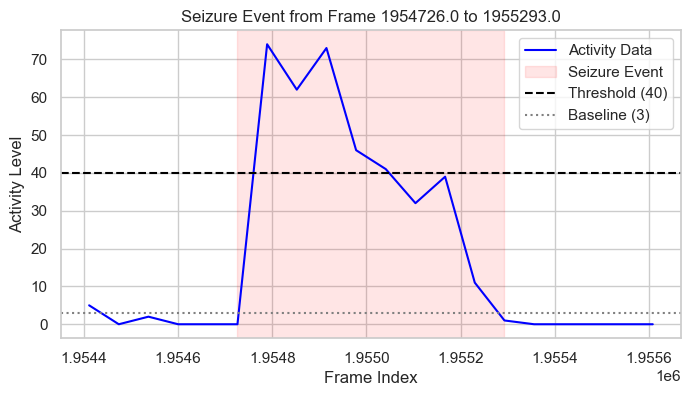

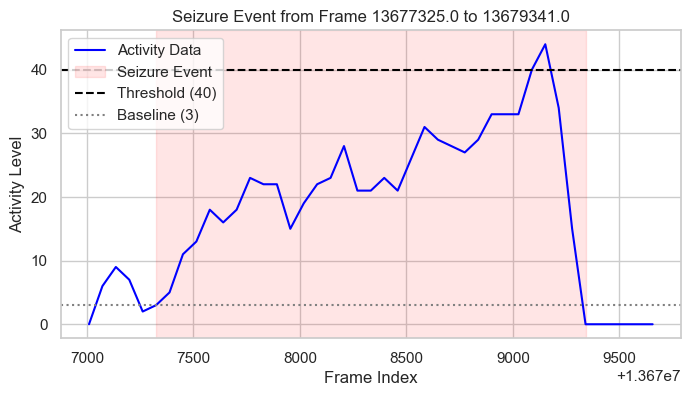

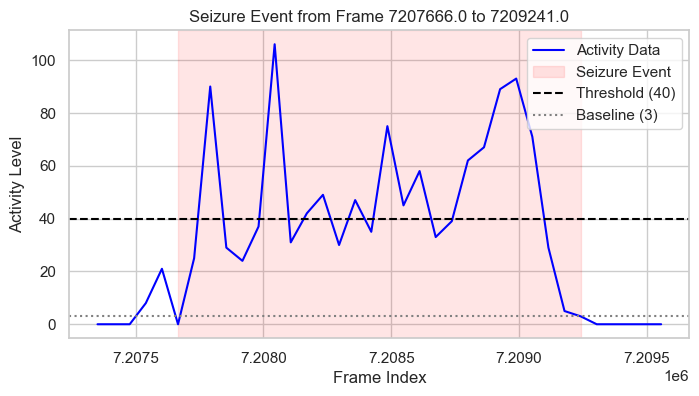

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# Load your dataset (replace with actual data file if needed)
# df_raw = pd.read_csv("your_data.csv")  # Uncomment if loading from file

# Filter for the specific well
fishC2 = df_raw[df_raw['well'] == 'C2'].copy()  # HOM

# Define thresholds
threshold = 40  # Activity level for potential seizure
lower_bound = 3  # Defines "zero" or near-zero baseline
min_duration = 8  # Minimum frames required to qualify as a seizure event
min_ibi = 8  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time (but maintain original index)
fishC2 = fishC2.sort_values(by="fullts")

# Create a boolean column indicating if data1 is above the threshold
fishC2["above_threshold"] = fishC2["data1"] >= threshold

# Initialize variables
seizure_events = []  # Stores (start_index, end_index, duration, IBI)
in_seizure = False  # Flag to track if we're currently in a seizure
start_index = None  # To store the start of the bout
end_index = None  # To store the end of the bout
last_end_index = None  # Tracks the last confirmed event's end

# Convert DataFrame index to a list to ensure correct referencing
frame_indices = fishC2.index.tolist()

# Detect seizure events
for i, row in fishC2.iterrows():
    if row["above_threshold"]:
        if not in_seizure:  # First frame crossing threshold
            for j in range(frame_indices.index(i), -1, -1):  # Look backward for bout start
                if fishC2.loc[frame_indices[j], "data1"] <= lower_bound:
                    start_index = frame_indices[j]
                    break
            in_seizure = True
    else:
        if in_seizure:  # Just dropped below threshold
            for j in range(frame_indices.index(i), len(frame_indices)):  # Look forward for bout end
                if fishC2.loc[frame_indices[j], "data1"] <= lower_bound:
                    end_index = frame_indices[j]
                    break
            duration = frame_indices.index(end_index) - frame_indices.index(start_index)

            if duration > min_duration:  # Only register if duration > 8 frames
                ibi = frame_indices.index(start_index) - frame_indices.index(last_end_index) if last_end_index is not None else None
                
                # Merge with the last event if IBI is too short
                if ibi is not None and ibi <= min_ibi:
                    last_event = seizure_events.pop()
                    new_event = (last_event[0], end_index, frame_indices.index(end_index) - frame_indices.index(last_event[0]), last_event[3])
                    seizure_events.append(new_event)
                else:
                    seizure_events.append((start_index, end_index, duration, ibi))

                last_end_index = end_index  # Update last end frame
            in_seizure = False
            start_index = None
            end_index = None

# If last event is still active, close it
if in_seizure:
    duration = frame_indices.index(frame_indices[-1]) - frame_indices.index(start_index)
    if duration > min_duration:
        ibi = frame_indices.index(start_index) - frame_indices.index(last_end_index) if last_end_index is not None else None
        seizure_events.append((start_index, frame_indices[-1], duration, ibi))

# Convert seizure events to DataFrame
seizure_df = pd.DataFrame(seizure_events, columns=["start", "end", "duration", "IBI"])

# Select 5 random seizure events (if available)
num_events_to_plot = min(5, len(seizure_df))
selected_events = seizure_df.sample(n=num_events_to_plot, random_state=42)

# Plot selected seizure events
for _, event in selected_events.iterrows():
    start, end = event["start"], event["end"]
    
    # Extend the window by 5 frames before and after the event
    start_idx = max(frame_indices.index(start) - 5, 0)
    end_idx = min(frame_indices.index(end) + 5, len(frame_indices) - 1)
    
    # Get the actual frame indices
    plot_start = frame_indices[start_idx]
    plot_end = frame_indices[end_idx]
    
    # Extract subset of data for plotting
    subset = fishC2.loc[plot_start:plot_end]

    # Plot the selected event window
    plt.figure(figsize=(8, 4))
    plt.plot(subset.index, subset["data1"], color="blue", label="Activity Data")
    plt.axvspan(start, end, color="red", alpha=0.1, label="Seizure Event")
    
    # Formatting
    plt.axhline(y=threshold, color='black', linestyle='--', label=f"Threshold ({threshold})")
    plt.axhline(y=lower_bound, color='gray', linestyle=':', label=f"Baseline ({lower_bound})")
    plt.xlabel("Frame Index")
    plt.ylabel("Activity Level")
    plt.title(f"Seizure Event from Frame {start} to {end}")
    plt.legend()
    plt.show()

In [61]:
seizure_df[(seizure_df['start'] > 6162810) & (seizure_df['start'] < 8162810)]
# seizure_df

,start,end,duration,IBI
96,6198217,6200044,29,534.0
97,6201493,6202123,10,23.0
98,6231166,6232615,23,461.0
99,6321949,6325981,64,1418.0
100,6371215,6373798,41,718.0
101,6475228,6476551,21,1610.0
102,6493183,6494065,14,264.0
103,6587179,6589636,39,1478.0
104,6615466,6617608,34,410.0
105,6643879,6646525,42,417.0


248680 253960 248680 253960


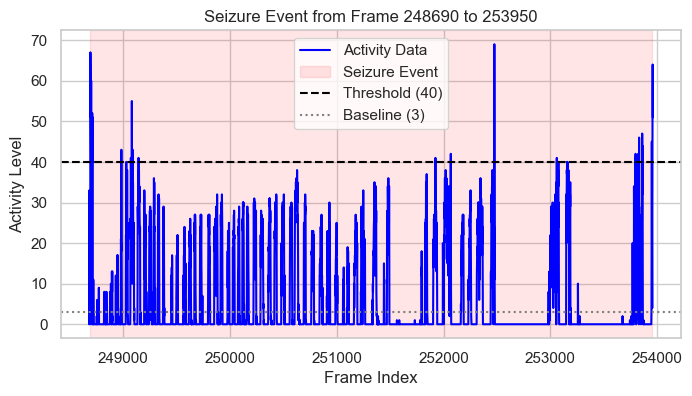

112380 113705 112380 113705


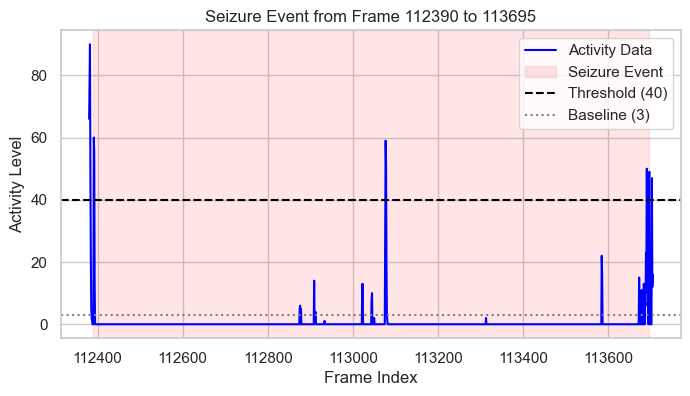

18364 18436 18364 18436


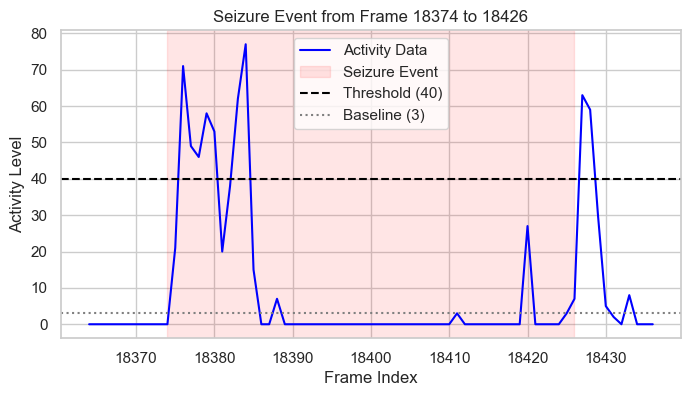

90328 90364 90328 90364


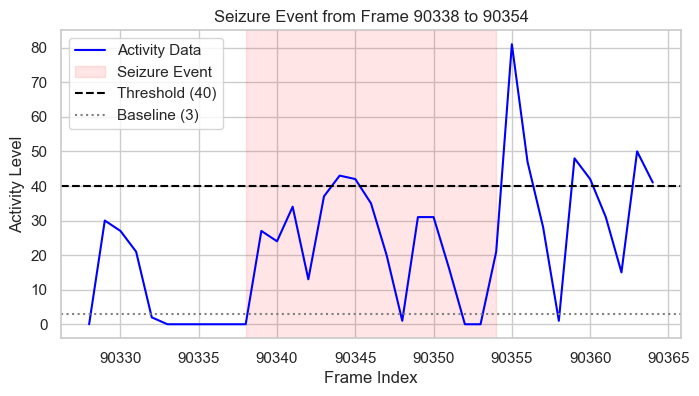

258752 259916 258752 259916


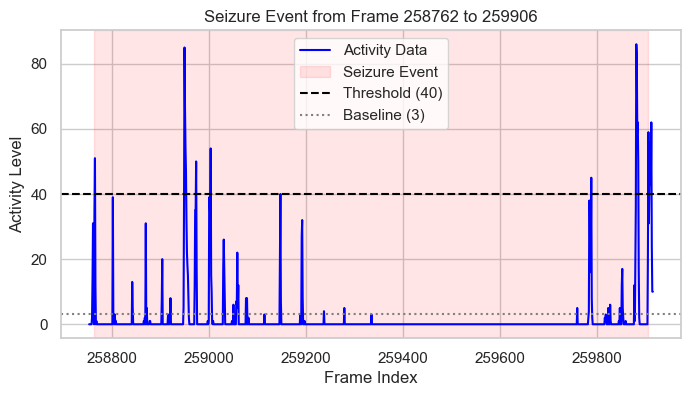

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# Load your dataset (replace with actual data file if needed)
# df_raw = pd.read_csv("your_data.csv")  # Uncomment if loading from file

# Filter for the specific well
fishC2 = df_raw[df_raw['well'] == 'C2'].copy()  # HOM

# Define thresholds
threshold = 40  # Activity level for potential seizure
lower_bound = 3  # Defines "zero" or near-zero baseline
min_duration = 8  # Minimum frames required to qualify as a seizure event
min_ibi = 2  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time (but maintain original index)
fishC2 = fishC2.sort_values(by="fullts", ignore_index=True)

# Create a boolean column indicating if data1 is above the threshold
fishC2["above_threshold"] = fishC2["data1"] >= threshold

# Initialize variables
seizure_events = []  # Stores (start_index, end_index, duration, IBI)
in_seizure = False  # Flag to track if we're currently in a seizure
start_index = None  # To store the start of the bout
end_index = None  # To store the end of the bout
last_end_index = None  # Tracks the last confirmed event's end


temp_frame_marker = None
frame_count_above = 0
min_frames_above = min_ibi  # Minimum frames above lower_bound to consider a separate event


# Convert DataFrame index to a list to ensure correct referencing
frame_indices = fishC2.index.tolist()

# Detect seizure events

for i, row in fishC2.iterrows():
    if row["above_threshold"]:
        if not in_seizure:  # First frame crossing threshold
            for j in range(i, -1, -1):  # Look backward for bout start
                if fishC2.loc[j, "data1"] <= lower_bound:
                    start_index = j
                    # print('START: ',start_index)
                    break
            in_seizure = True
            temp_frame_marker = None  # Reset temporary marker when a seizure starts
            frame_count_above = 0  # Reset frame counter
    else:
        if in_seizure:  # Just dropped below threshold
            if temp_frame_marker is None:
                temp_frame_marker = i  # Set temporary marker for a potential end
                # print('temp_frame_marker1: ', temp_frame_marker)
            else:
                frame_count_above = 0
                for j in range(temp_frame_marker, i):  # Count frames above lower_bound
                    if fishC2.loc[j, "data1"] > lower_bound:
                        frame_count_above += 1
                        # print('frame_count_above): ',frame_count_above)

                # print(frame_count_above)
                if frame_count_above < min_frames_above: # if less than 5, which means it's same event
                    temp_frame_marker = i  # Replace temporary marker
                    # print('temp_frame_marker2: ', temp_frame_marker)
                else:
                    end_index        = temp_frame_marker  # Confirm the event end
                    next_start_index = end_index + frame_count_above
                    duration = end_index - start_index
                    # print('duration: ',duration)
                    if duration > min_duration:  # Only register if duration > 8 frames
                        # print('duration is more than 8 frames? ',duration > min_duration)
                        ibi = next_start_index - end_index if end_index is not None else None
                        # print('ibi: ',ibi,'=',next_start_index,'-',end_index)

                        # Merge with the last event if IBI is too short
                        if ibi is not None and ibi <= min_ibi:
                            if seizure_events:
                                last_event = seizure_events.pop()
                                # print(last_event)
                                new_event = (last_event[0], end_index, end_index - last_event[0], last_event[3])
                                seizure_events.append(new_event)
                            else:
                                seizure_events.append((start_index, end_index, duration, ibi))
                            
                        else:
                            seizure_events.append((start_index, end_index, duration, ibi))
                            # print('END: ',end_index)

                        last_end_index = end_index  # Update last end frame
                
                    
                    in_seizure = False
                    start_index = None
                    end_index = None
                    temp_frame_marker = None  # Reset temporary marker


# If last event is still active, close it
if in_seizure:
    duration = len(fishC2) - start_index
    if duration > min_duration:
        ibi = start_index - last_end_index if last_end_index is not None else None
        seizure_events.append((start_index, len(fishC2) - 1, duration, ibi))


# Convert seizure events to DataFrame
seizure_df = pd.DataFrame(seizure_events, columns=["start", "end", "duration", "IBI"])

# Select 5 random seizure events (if available)
num_events_to_plot = min(5, len(seizure_df))
selected_events = seizure_df.sample(n=num_events_to_plot, random_state=42)

# Plot selected seizure events
for _, event in selected_events.iterrows():
    start, end = event["start"], event["end"]
    
    # Extend the window by 5 frames before and after the event
    start_idx = max(frame_indices.index(start) - 10, 0)
    end_idx = min(frame_indices.index(end) + 10, len(frame_indices) - 1)
    
    # Get the actual frame indices
    # plot_start = frame_indices[start_idx]
    # plot_end = frame_indices[end_idx]
    plot_start = start_idx
    plot_end = end_idx

    print(start_idx, end_idx, plot_start, plot_end)
    
    # Extract subset of data for plotting
    subset = fishC2.loc[plot_start:plot_end]

    # Plot the selected event window
    plt.figure(figsize=(8, 4))
    plt.plot(subset.index, subset["data1"], color="blue", label="Activity Data")
    plt.axvspan(start, end, color="red", alpha=0.1, label="Seizure Event")
    
    # Formatting
    plt.axhline(y=threshold, color='black', linestyle='--', label=f"Threshold ({threshold})")
    plt.axhline(y=lower_bound, color='gray', linestyle=':', label=f"Baseline ({lower_bound})")
    plt.xlabel("Frame Index")
    plt.ylabel("Activity Level")
    plt.title(f"Seizure Event from Frame {start} to {end}")
    plt.legend()
    plt.show()

In [ ]:
# Output detected seizure events with IBI
for event in seizure_events:
    print(f"Seizure from frame {event[0]} to {event[1]} (Duration: {event[2]} frames, IBI: {event[3]} frames)")

In [92]:
fishC2.head(31)

,fullts,elapsed_time,box,well,genotype,data1,above_threshold,below_threshold
0,2025-02-14 10:07:08.027045000,0.000000,14,C2,HOM,0.0,False,True
1,2025-02-14 10:07:08.059016000,0.000533,14,C2,HOM,0.0,False,True
2,2025-02-14 10:07:08.097652000,0.001177,14,C2,HOM,0.0,False,True
3,2025-02-14 10:07:08.180832000,0.002563,14,C2,HOM,51.0,True,False
4,2025-02-14 10:07:08.217890000,0.003181,14,C2,HOM,65.0,True,False
5,2025-02-14 10:07:08.261256000,0.003904,14,C2,HOM,76.0,True,False
6,2025-02-14 10:07:08.327175000,0.005002,14,C2,HOM,64.0,True,False
7,2025-02-14 10:07:08.337880000,0.005181,14,C2,HOM,0.0,False,True
8,2025-02-14 10:07:08.383972000,0.005949,14,C2,HOM,0.0,False,True
9,2025-02-14 10:07:08.417435000,0.006507,14,C2,HOM,0.0,False,True


In [111]:
# Filter for the specific well
fishC2 = df_raw[df_raw['well'] == 'C2'].copy()  # HOM

# Define thresholds
upper_threshold    = 40  # Activity level for potential seizure
lower_threshold    = 1  # Defines "zero" or near-zero baseline
min_frame_duration = 8  # Minimum frames required to qualify as a seizure event
min_ibi            = 5  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time (but maintain original index)
fishC2 = fishC2.sort_values(by="fullts", ignore_index=True)

# Create a boolean column indicating if data1 is above the threshold
fishC2["above_threshold"] = fishC2["data1"] >= upper_threshold
fishC2["below_threshold"] = fishC2["data1"] <= lower_threshold

# Initialize variables
seizure_events = []  # Stores (start_index, end_index, duration, IBI)
in_seizure     = False  # Flag to track if we're currently in a seizure
start_index    = None  # To store the start of the bout
end_index      = None  # To store the end of the bout

next_start_index = None  # Tracks the next event's start

potential_event_end = None
frame_count = 0

# Convert DataFrame index to a list to ensure correct referencing
frame_indices = fishC2.index.tolist()

# Detect seizure events

for i, row in fishC2.iterrows():
    print(i)
    if row["above_threshold"]:
        print("^ this one is above threshold")
        if not in_seizure:
            for j in range(i, -1, -1): # Look backward for bout start
                if fishC2.loc[j, 'below_threshold']:
                    start_index = j
                    print("START: index=",start_index, "elapsed_time=",fishC2.loc[start_index, 'elapsed_time'])
                    break
            in_seizure = True
    else: # if row is not above upper threshold
        if in_seizure: # but still in seizure and data1 is below the lower threshold
            if row["below_threshold"]:
                if potential_event_end == None:
                    potential_event_end = i
                else:
                    frame_count += 1
                print(f"This is a potential end; {frame_count}")
            else:
                print('below_lthres count:',frame_count)
                if frame_count > min_ibi:
                    end_index = potential_event_end
                    ibi = frame_count
                    print(f'END: {end_index}, ibi: {ibi}')
                    

                    in_seizure = False
                    start_index = end_index + ibi
                    end_index = None
                    potential_event_end = None  # Reset temporary marker
                    frame_count = 0


            # print('MARKED: ',potential_event_end)
                
            # for j in range(temp_frame_marker, i):
            #     if fishC2.loc[j, 'below_threshold']:
            #         print(j)
    print('___next row___')
        
            
    if i == 50: break

0
___next row___
1
___next row___
2
___next row___
3
^ this one is above threshold
START: index= 2 elapsed_time= 0.0011767833333333
___next row___
4
^ this one is above threshold
___next row___
5
^ this one is above threshold
___next row___
6
^ this one is above threshold
___next row___
7
This is a potential end; 0
___next row___
8
This is a potential end; 1
___next row___
9
This is a potential end; 2
___next row___
10
This is a potential end; 3
___next row___
11
This is a potential end; 4
___next row___
12
This is a potential end; 5
___next row___
13
This is a potential end; 6
___next row___
14
This is a potential end; 7
___next row___
15
This is a potential end; 8
___next row___
16
This is a potential end; 9
___next row___
17
This is a potential end; 10
___next row___
18
This is a potential end; 11
___next row___
19
below_lthres count: 11
END: 7, ibi: 11
___next row___
20
___next row___
21
^ this one is above threshold
START: index= 18 elapsed_time= 0.0132770166666666
___next row___
